<a href="https://colab.research.google.com/github/aven330/Sharpe_Ratio/blob/main/Sharpe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,SPY
Results,,
Simple Returns,0.524987,0.509090
Log_Returns,0.421986,0.411507
Sharpe Ratio,0.373582,0.442348


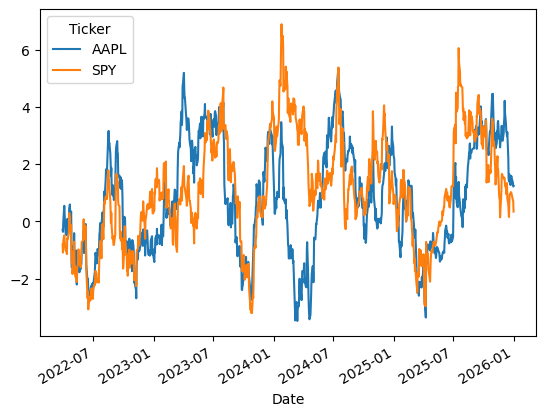

In [ ]:
import numpy as np
import yfinance as yf
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
def Sharpe(ticker_symbols, start, end, risk_free_rate = 0.04):
    # Constants
    trading_days_in_year = 252
    window = 60 # Quarterly
    # Ticker and Spy Data
    data = pd.DataFrame(yf.download(ticker_symbols, start = start, end = end, auto_adjust = True))
    # Extracting Closing Data
    closing_data = data['Close'].dropna()
    # Evaluating Daily Returns
    daily_returns = closing_data.pct_change().dropna()
    num_days = len(daily_returns)
    # Evaluating Simple Returns
    simple_returns = (closing_data.iloc[-1] - closing_data.iloc[0])/(closing_data.iloc[0])
    # Evaluating Log Returns
    log_returns = np.log((closing_data.iloc[-1])/(closing_data.iloc[0]))
    # Mean Returns
    daily_mean_returns = daily_returns.mean()
    # Standard Deviation Returns
    daily_std_returns = daily_returns.std()
    # Annualized Returns = Mean of daily returns multiplied by number of periods in the time horizon
    annualized_returns = daily_mean_returns * trading_days_in_year
    # Annualized Volatility = Standard Deviation of Returns mulitplied by sqrt of number of periods in the time horizon
    annualized_volatility = daily_std_returns*np.sqrt(trading_days_in_year)
    annualized_volatility = annualized_volatility.replace(0, np.nan)
    # Sharpe Ratio = measures the average return earned in excess of the risk-free rate per unit of total risk
    # If annualized_velocity is 0 then sharpe_ratio will error so we create an edge case to prevent that
    sharpe_ratio = (annualized_returns - risk_free_rate)  / annualized_volatility
    # Rolling Sharpe Ratio
    rolling_mean = daily_returns.rolling(window).mean()
    rolling_std = daily_returns.rolling(window).std()
    rolling_returns = rolling_mean * trading_days_in_year
    rolling_volatility =rolling_std * np.sqrt(trading_days_in_year)
    rolling_sharpe_ratio = ((rolling_returns - risk_free_rate) / (rolling_volatility)).dropna()
    # Result
    results = pd.DataFrame((simple_returns, log_returns, sharpe_ratio), index = pd.Index(['Simple Returns','Log_Returns', 'Sharpe Ratio'], name = 'Results'))
    rolling_sharpe_ratio.plot()
    return results
## Example
Sharpe(['AAPL', 'SPY'], '2022-01-01', '2026-01-01')